---

# NOTEBOOK 1: 01 - Xây dựng bảng trung gian theo ngày (Daily Intermediate Tables)

---

# 01 - Xây dựng bảng trung gian theo ngày (Daily Intermediate Tables)
## Mục tiêu kinh doanh
Chuẩn hóa dữ liệu vận hành e-commerce về cùng hạt thời gian theo ngày để doanh nghiệp có thể dự báo doanh thu, lập kế hoạch tồn kho, ngân sách marketing và năng lực fulfillment.

## Vai trò trong pipeline mô hình
Đây là lớp dữ liệu nền tảng. Nếu bước này sai grain hoặc sai logic tổng hợp, toàn bộ mô hình phía sau sẽ lệch tín hiệu và dẫn đến quyết định kinh doanh sai.

## Đầu vào
- Các bảng sạch dạng parquet trong thư mục dataset/interim/*_base.parquet

## Đầu ra
- dataset/interim/daily/sales_daily.parquet
- dataset/interim/daily/web_traffic_daily.parquet
- dataset/interim/daily/orders_daily.parquet
- dataset/interim/daily/payments_daily.parquet
- dataset/interim/daily/order_items_daily.parquet
- dataset/interim/daily/promotions_daily.parquet
- dataset/interim/daily/returns_daily.parquet
- dataset/interim/daily/reviews_daily.parquet
- dataset/interim/daily/shipments_daily.parquet
- dataset/interim/daily/inventory_monthly_summary.parquet

## Giải thích chuyên môn theo nghiệp vụ e-commerce
1. sales_daily: tạo đường cơ sở GMV/Revenue và COGS theo ngày để đo hiệu quả kinh doanh thuần.
2. web_traffic_daily: gom traffic để liên kết đầu phễu (sessions, visitors) với đầu ra doanh thu.
3. orders_daily: theo dõi sức khỏe chuyển đổi và chất lượng đơn (cancelled, delivered, returned).
4. payments_daily: phản ánh hành vi thanh toán, sức mua thực trả và đặc điểm trả góp.
5. order_items_daily: đo cường độ bán theo sản phẩm, mức độ phụ thuộc khuyến mại và stacked promo.
6. promotions_daily: lượng hóa áp lực khuyến mại theo từng ngày để tách tác động giá/khuyến mãi khỏi nhu cầu tự nhiên.
7. returns_daily + reviews_daily + shipments_daily: bổ sung tín hiệu hậu mãi, trải nghiệm giao hàng, chất lượng sản phẩm; đây là nhóm biến có tác động gián tiếp nhưng bền vững đến doanh thu.
8. inventory_monthly_summary: đưa tín hiệu cung ứng (stockout, fill rate, days of supply) vào mô hình để bắt hiện tượng mất doanh thu do thiếu hàng.

## Giá trị cho doanh nghiệp
- Giúp ban điều hành nhìn cùng lúc 3 trục tăng trưởng: nhu cầu thị trường, năng lực vận hành, và chất lượng trải nghiệm khách hàng.
- Tạo tiền đề để dự báo doanh thu có thể hành động được: dự báo xong có thể quy về quyết định ngân sách, tồn kho, và năng lực vận chuyển.
- Giảm rủi ro dùng dữ liệu rời rạc dẫn đến overfit hoặc ra quyết định cảm tính.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "model" else Path.cwd().resolve()
BASE_DIR = PROJECT_ROOT / "dataset" / "interim"
OUT_DIR = PROJECT_ROOT / "dataset" / "interim" / "daily"
os.makedirs(OUT_DIR, exist_ok=True)

def read_tbl(name):
    p = BASE_DIR / f"{name}_base.parquet"
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}")
    return pd.read_parquet(p)

def to_dt(s):
    return pd.to_datetime(s, errors="coerce")

In [2]:
# 1) sales_daily
sales = read_tbl("sales").copy()
sales["date"] = to_dt(sales["date"])
sales_daily = (
    sales.groupby("date", as_index=False)
    .agg(revenue=("revenue", "sum"), cogs=("cogs", "sum"))
    .rename(columns={"date": "Date", "revenue": "Revenue", "cogs": "COGS"})
)
sales_daily.to_parquet(os.path.join(OUT_DIR, "sales_daily.parquet"), index=False)
sales_daily.head()

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [3]:
# 2) web_traffic_daily
wt = read_tbl("web_traffic").copy()
wt["date"] = to_dt(wt["date"])
web_traffic_daily = (
    wt.groupby("date", as_index=False).agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        bounce_rate=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean")
    )
    .rename(columns={"date": "Date"})
)
web_traffic_daily.to_parquet(os.path.join(OUT_DIR, "web_traffic_daily.parquet"), index=False)
web_traffic_daily.head()

,Date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
0,2013-01-01,9760,7253,39093,0.00514,102.9
1,2013-01-02,10456,8151,47611,0.00406,120.5
2,2013-01-03,10076,7458,36963,0.00401,263.6
3,2013-01-04,9973,8063,53078,0.00562,151.8
4,2013-01-05,10223,7882,36790,0.00525,168.6


In [4]:
# 3) orders_daily
orders = read_tbl("orders").copy()
orders["order_date"] = to_dt(orders["order_date"])

orders_daily = orders.groupby("order_date", as_index=False).agg(
    total_orders=("order_id", "nunique"),
    cancelled_orders=("order_status", lambda s: (s == "cancelled").sum()),
    delivered_orders=("order_status", lambda s: (s == "delivered").sum()),
    returned_orders=("order_status", lambda s: (s == "returned").sum())
).rename(columns={"order_date": "Date"})

device_daily = pd.crosstab(orders["order_date"], orders["device_type"]).reset_index()
device_daily.columns = ["Date"] + [f"orders_device_{c}" for c in device_daily.columns[1:]]

source_daily = pd.crosstab(orders["order_date"], orders["order_source"]).reset_index()
source_daily.columns = ["Date"] + [f"orders_source_{c}" for c in source_daily.columns[1:]]

orders_daily = orders_daily.merge(device_daily, on="Date", how="left").merge(source_daily, on="Date", how="left")
orders_daily.to_parquet(os.path.join(OUT_DIR, "orders_daily.parquet"), index=False)
orders_daily.head()

,Date,total_orders,cancelled_orders,delivered_orders,returned_orders,orders_device_desktop,orders_device_mobile,orders_device_tablet,orders_source_direct,orders_source_email_campaign,orders_source_organic_search,orders_source_paid_search,orders_source_referral,orders_source_social_media
0,2012-07-04,162,9,134,11,67,69,26,9,14,52,30,16,41
1,2012-07-05,97,9,81,5,43,38,16,6,11,26,18,9,27
2,2012-07-06,93,11,69,7,42,42,9,10,12,28,23,7,13
3,2012-07-07,73,8,55,6,26,34,13,2,13,20,15,12,11
4,2012-07-08,88,5,67,8,30,45,13,7,11,22,18,2,28


In [5]:
# 4) payments_daily (join orders -> order_date)
payments = read_tbl("payments").copy()
pay_join = payments.merge(orders[["order_id", "order_date"]], on="order_id", how="left")
pay_join["order_date"] = to_dt(pay_join["order_date"])

payments_daily = pay_join.groupby("order_date", as_index=False).agg(
    total_payment_value=("payment_value", "sum"),
    avg_payment_value=("payment_value", "mean"),
    avg_installments=("installments", "mean")
).rename(columns={"order_date": "Date"})

payments_daily.to_parquet(os.path.join(OUT_DIR, "payments_daily.parquet"), index=False)
payments_daily.head()

,Date,total_payment_value,avg_payment_value,avg_installments
0,2012-07-04,5123547.94,31626.839136,3.790123
1,2012-07-05,2751773.45,28368.798454,3.917526
2,2012-07-06,3054029.42,32839.026022,4.139785
3,2012-07-07,2667930.94,36546.999178,2.904110
4,2012-07-08,2360851.90,26827.862500,3.465909


In [6]:
# 5) order_items_daily (join orders -> order_date)
oi = read_tbl("order_items").copy()
oi_join = oi.merge(orders[["order_id", "order_date"]], on="order_id", how="left")
oi_join["order_date"] = to_dt(oi_join["order_date"])

oi_join["promo_line"] = oi_join["promo_id"].notna().astype(int)
oi_join["stacked_promo_line"] = (oi_join["promo_id"].notna() & oi_join["promo_id_2"].notna()).astype(int)

order_items_daily = oi_join.groupby("order_date", as_index=False).agg(
    total_quantity_sold=("quantity", "sum"),
    total_discount_amount=("discount_amount", "sum"),
    promo_line_count=("promo_line", "sum"),
    stacked_promo_count=("stacked_promo_line", "sum")
).rename(columns={"order_date": "Date"})

order_items_daily.to_parquet(os.path.join(OUT_DIR, "order_items_daily.parquet"), index=False)
order_items_daily.head()

,Date,total_quantity_sold,total_discount_amount,promo_line_count,stacked_promo_count
0,2012-07-04,777,0.0,0,0
1,2012-07-05,428,0.0,0,0
2,2012-07-06,441,0.0,0,0
3,2012-07-07,364,0.0,0,0
4,2012-07-08,394,0.0,0,0


In [7]:
# 6) promotions_daily (expand date range active)
promos = read_tbl("promotions").copy()
promos["start_date"] = to_dt(promos["start_date"])
promos["end_date"] = to_dt(promos["end_date"])

rows = []
for _, r in promos.dropna(subset=["start_date", "end_date"]).iterrows():
    rng = pd.date_range(r["start_date"], r["end_date"], freq="D")
    rows.append(pd.DataFrame({
        "Date": rng,
        "promo_id": r.get("promo_id", np.nan),
        "discount_value": r.get("discount_value", np.nan)
    }))

promo_expanded = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["Date", "promo_id", "discount_value"])

promotions_daily = promo_expanded.groupby("Date", as_index=False).agg(
    active_promo_count=("promo_id", "nunique"),
    avg_discount_value=("discount_value", "mean")
)
promotions_daily["has_any_promo"] = (promotions_daily["active_promo_count"] > 0).astype(int)

promotions_daily.to_parquet(os.path.join(OUT_DIR, "promotions_daily.parquet"), index=False)
promotions_daily.head()

,Date,active_promo_count,avg_discount_value,has_any_promo
0,2013-01-31,1,15.0,1
1,2013-02-01,1,15.0,1
2,2013-02-02,1,15.0,1
3,2013-02-03,1,15.0,1
4,2013-02-04,1,15.0,1


In [8]:
# 7) returns_daily
rets = read_tbl("returns").copy()
rets["return_date"] = to_dt(rets["return_date"])

return_id_col = "return_id" if "return_id" in rets.columns else rets.columns[0]
refund_col = "refund_amount" if "refund_amount" in rets.columns else None
return_agg = {"return_count": (return_id_col, "count")}
if refund_col is not None:
    return_agg["total_refund_amount"] = (refund_col, "sum")
returns_daily = rets.groupby("return_date", as_index=False).agg(**return_agg).rename(columns={"return_date": "Date"})
returns_daily.to_parquet(os.path.join(OUT_DIR, "returns_daily.parquet"), index=False)

# 8) reviews_daily
reviews = read_tbl("reviews").copy()
reviews["review_date"] = to_dt(reviews["review_date"])

review_id_col = "review_id" if "review_id" in reviews.columns else reviews.columns[0]
rating_col = "rating" if "rating" in reviews.columns else None
review_agg = {"review_count": (review_id_col, "count")}
if rating_col is not None:
    review_agg["avg_rating"] = (rating_col, "mean")
reviews_daily = reviews.groupby("review_date", as_index=False).agg(**review_agg).rename(columns={"review_date": "Date"})
reviews_daily.to_parquet(os.path.join(OUT_DIR, "reviews_daily.parquet"), index=False)

# 9) shipments_daily
ship = read_tbl("shipments").copy()
ship["ship_date"] = to_dt(ship["ship_date"])

if "delivery_date" in ship.columns:
    ship["delivery_date"] = to_dt(ship["delivery_date"])

    ship["delivery_days"] = (ship["delivery_date"] - ship["ship_date"]).dt.days
else:
    ship["delivery_days"] = np.nan

shipment_id_col = "shipment_id" if "shipment_id" in ship.columns else ("order_id" if "order_id" in ship.columns else ship.columns[0])
shipping_fee_col = "shipping_fee" if "shipping_fee" in ship.columns else None

ship_agg = {
    "shipment_count": (shipment_id_col, "count"),
    "avg_delivery_days": ("delivery_days", "mean")
}
if shipping_fee_col is not None:
    ship_agg["avg_shipping_fee"] = (shipping_fee_col, "mean")

shipments_daily = ship.groupby("ship_date", as_index=False).agg(**ship_agg).rename(columns={"ship_date": "Date"})
shipments_daily.to_parquet(os.path.join(OUT_DIR, "shipments_daily.parquet"), index=False)

# 10) inventory_monthly_summary
inv = read_tbl("inventory").copy()
inv["snapshot_date"] = to_dt(inv["snapshot_date"])

inv["year"] = inv["snapshot_date"].dt.year
inv["month"] = inv["snapshot_date"].dt.month
inventory_monthly_summary = inv.groupby(["year", "month"], as_index=False).agg(
    avg_stockout_days=("stockout_days", "mean"),
    avg_fill_rate=("fill_rate", "mean"),
    avg_days_of_supply=("days_of_supply", "mean"),
    avg_sell_through_rate=("sell_through_rate", "mean"),
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    reorder_rate=("reorder_flag", "mean")
)
inventory_monthly_summary.to_parquet(os.path.join(OUT_DIR, "inventory_monthly_summary.parquet"), index=False)

print("Done building daily/monthly tables in", OUT_DIR)

Done building daily/monthly tables in D:\UNIVERSITY\PERSONAL_PROJECT\datathon\dataset\interim\daily


---

# NOTEBOOK 2: 02 - Xây dựng bảng đặc trưng cuối cùng theo ngày (Daily Feature Table)

---

# 02 - Xây dựng bảng đặc trưng cuối cùng theo ngày (Daily Feature Table)
## Mục tiêu kinh doanh
Hợp nhất toàn bộ tín hiệu đa phòng ban (marketing, thương mại, vận hành, hậu mãi, tồn kho) vào một bảng duy nhất theo ngày để huấn luyện mô hình dự báo Revenue.

## Vai trò trong pipeline mô hình
Đây là tập dữ liệu train chính thức cho mô hình. Mỗi dòng đại diện cho một ngày kinh doanh; mỗi cột là một tín hiệu có thể giải thích biến động doanh thu.

## Đầu vào
- Các bảng daily/monthly được tạo từ notebook 01
- sales_daily đóng vai trò bảng gốc

## Đầu ra
- dataset/interim/daily_feature_table.parquet

## Logic triển khai
1. Chuẩn hóa Date ở tất cả bảng để tránh lỗi join và lệch timezone/định dạng.
2. Left join tuần tự vào sales_daily để giữ đúng grain 1 dòng/ngày.
3. Join inventory_monthly_summary theo year-month để thêm bối cảnh cung ứng.
4. Xử lý missing theo bản chất nghiệp vụ:
   - biến đếm/tổng (count, total, sessions...): điền 0 vì không phát sinh sự kiện
   - biến tỷ lệ/trung bình: ffill rồi median fallback để ổn định mô hình
5. Sắp xếp theo Date, loại trùng ngày, lưu file final.
6. Data quality checks: Date không null, không trùng, có đầy đủ cột Revenue.

## Giá trị cho doanh nghiệp
- Tạo “single source of truth” cho bài toán dự báo doanh thu ngày.
- Tăng khả năng phối hợp liên phòng ban vì mọi tín hiệu được thống nhất trên cùng trục thời gian.
- Giúp mô hình học được tương tác thực tế giữa marketing, khuyến mại, vận hành và tồn kho, từ đó nâng chất lượng dự báo.

In [9]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "model" else Path.cwd().resolve()
IN_DIR = PROJECT_ROOT / "dataset" / "interim" / "daily"
OUT_PATH = PROJECT_ROOT / "dataset" / "interim" / "daily_feature_table.parquet"

def rd(name):
    p = IN_DIR / f"{name}.parquet"
    if not os.path.exists(p):
        raise FileNotFoundError(p)
    df = pd.read_parquet(p)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    return df

sales_daily = rd("sales_daily")
web_traffic_daily = rd("web_traffic_daily")
orders_daily = rd("orders_daily")
payments_daily = rd("payments_daily")
order_items_daily = rd("order_items_daily")
promotions_daily = rd("promotions_daily")
returns_daily = rd("returns_daily")
reviews_daily = rd("reviews_daily")
shipments_daily = rd("shipments_daily")
inventory_monthly_summary = rd("inventory_monthly_summary")

In [10]:
# Merge all daily tables on Date
daily = sales_daily.copy()
for t in [web_traffic_daily, orders_daily, payments_daily, order_items_daily, promotions_daily, returns_daily, reviews_daily, shipments_daily]:
    daily = daily.merge(t, on="Date", how="left")

# Join inventory by year-month
daily["year"] = daily["Date"].dt.year
daily["month"] = daily["Date"].dt.month
daily = daily.merge(inventory_monthly_summary, on=["year", "month"], how="left")

# Missing value policy
sum_count_cols = [c for c in daily.columns if any(x in c for x in ["count", "total", "orders_", "sessions", "visitors", "page_views"])]
for c in sum_count_cols:
    daily[c] = daily[c].fillna(0)

for c in daily.columns:
    if c not in ["Date"] and daily[c].dtype.kind in "biufc":
        daily[c] = daily[c].ffill()
        daily[c] = daily[c].fillna(daily[c].median())

daily = daily.sort_values("Date").drop_duplicates(subset=["Date"]).reset_index(drop=True)
daily.to_parquet(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Shape:", daily.shape)
daily.head()

Saved: D:\UNIVERSITY\PERSONAL_PROJECT\datathon\dataset\interim\daily_feature_table.parquet
Shape: (3833, 47)


,Date,Revenue,COGS,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,total_orders,cancelled_orders,...,avg_shipping_fee,year,month,avg_stockout_days,avg_fill_rate,avg_days_of_supply,avg_sell_through_rate,stockout_rate,overstock_rate,reorder_rate
0,2012-07-04,5123547.94,3982991.19,0.0,0.0,0.0,0.00445,209.2,162,9,...,4.780606,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0
1,2012-07-05,2751773.45,2150580.23,0.0,0.0,0.0,0.00445,209.2,97,9,...,3.838889,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0
2,2012-07-06,3054029.42,2517632.84,0.0,0.0,0.0,0.00445,209.2,93,11,...,3.107979,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0
3,2012-07-07,2667930.94,2108246.62,0.0,0.0,0.0,0.00445,209.2,73,8,...,3.571522,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0
4,2012-07-08,2360851.90,1808622.79,0.0,0.0,0.0,0.00445,209.2,88,5,...,5.489487,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0


In [11]:
# Data quality checks
assert daily["Date"].isna().sum() == 0, "Date has NaN"
assert daily["Date"].duplicated().sum() == 0, "Duplicate Date found"
assert "Revenue" in daily.columns, "Missing target Revenue"
print("DQ checks passed")
daily.describe(include="all").T.head(20)

DQ checks passed


,count,mean,min,25%,50%,75%,max,std
Date,3833,2017-10-02 00:00:00,2012-07-04 00:00:00,2015-02-17 00:00:00,2017-10-02 00:00:00,2020-05-17 00:00:00,2022-12-31 00:00:00,NaN
Revenue,3833.0,4286584.029619,279813.94,2471088.82,3647303.9,5350877.2,20905271.35,2624840.198186
COGS,3833.0,3695134.494957,236576.31,2150580.23,3161112.99,4637293.92,16535857.67,2219788.768582
sessions,3833.0,23859.258283,0.0,16323.0,22915.0,31417.0,50947.0,10621.348988
unique_visitors,3833.0,18132.713019,0.0,12395.0,17237.0,23808.0,40430.0,8137.16455
page_views,3833.0,103486.250978,0.0,69094.0,98147.0,136032.0,275560.0,49145.326763
bounce_rate,3833.0,0.004486,0.0032,0.00387,0.00445,0.00512,0.0058,0.000735
avg_session_duration_sec,3833.0,210.23209,100.1,159.1,209.2,263.5,319.9,62.247827
total_orders,3833.0,168.782938,8.0,92.0,139.0,217.0,803.0,111.05635
cancelled_orders,3833.0,15.513175,0.0,8.0,13.0,20.0,77.0,10.870964


---

# NOTEBOOK 3: 03 - Baseline, mô hình chính và Walk-Forward Evaluation

---

# 03 - Baseline, mô hình chính và Walk-Forward Evaluation
## Mục tiêu nộp thi
Xây dựng pipeline dự báo Revenue theo ngày đáp ứng đầy đủ ràng buộc: không dùng dữ liệu ngoài, tái lập được, có khả năng giải thích và kiểm soát leakage.

## Ràng buộc đã áp dụng trong notebook này
1. Chỉ dùng dữ liệu nội bộ từ `dataset/interim/daily_feature_table.parquet`.
2. Thiết lập random seed để tái lập kết quả mô hình.
3. Chia tập theo thời gian (không random split).
4. Có baseline (`lag_1`, `lag_365`) trước khi đánh giá model chính.
5. Bổ sung walk-forward evaluation để phản ánh tính ổn định theo thời gian.

## Đầu vào
- dataset/interim/daily_feature_table.parquet

## Đầu ra
- report/model_metrics.csv
- report/model_predictions_valid_test.parquet
- report/walk_forward_metrics.csv

## Ý nghĩa kinh doanh
- Baseline cho biết mức dự báo tối thiểu có thể đạt nếu chỉ dựa vào quán tính doanh thu.
- LightGBM cung cấp dự báo chính xác hơn để lập kế hoạch doanh thu, tồn kho và ngân sách marketing.
- Walk-forward cho thấy mô hình có bền vững qua các giai đoạn thị trường khác nhau hay không.

In [12]:
import os
import random
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    HAS_LGB = False
    print("LightGBM not installed. Run: pip install lightgbm")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "model" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "dataset" / "interim" / "daily_feature_table.parquet"
df = pd.read_parquet(DATA_PATH).sort_values("Date").reset_index(drop=True)
df["Date"] = pd.to_datetime(df["Date"])

print(f"SEED={SEED}")
df.head()

SEED=42


,Date,Revenue,COGS,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,total_orders,cancelled_orders,...,avg_shipping_fee,year,month,avg_stockout_days,avg_fill_rate,avg_days_of_supply,avg_sell_through_rate,stockout_rate,overstock_rate,reorder_rate
0,2012-07-04,5123547.94,3982991.19,0.0,0.0,0.0,0.00445,209.2,162,9,...,4.780606,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0
1,2012-07-05,2751773.45,2150580.23,0.0,0.0,0.0,0.00445,209.2,97,9,...,3.838889,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0
2,2012-07-06,3054029.42,2517632.84,0.0,0.0,0.0,0.00445,209.2,93,11,...,3.107979,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0
3,2012-07-07,2667930.94,2108246.62,0.0,0.0,0.0,0.00445,209.2,73,8,...,3.571522,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0
4,2012-07-08,2360851.90,1808622.79,0.0,0.0,0.0,0.00445,209.2,88,5,...,5.489487,2012,7,1.017722,0.966075,93.253165,0.243548,0.668354,0.594937,0.0


In [13]:
# Calendar features
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["dayofweek"] = df["Date"].dt.dayofweek
df["dayofmonth"] = df["Date"].dt.day
df["weekend_flag"] = (df["dayofweek"] >= 5).astype(int)

# Lag features
for lag in [1, 7, 14, 30, 365]:
    df[f"lag_{lag}"] = df["Revenue"].shift(lag)

# Rolling features without leakage
df["rolling_mean_7"] = df["Revenue"].shift(1).rolling(7).mean()
df["rolling_mean_30"] = df["Revenue"].shift(1).rolling(30).mean()
df["rolling_std_7"] = df["Revenue"].shift(1).rolling(7).std()
df["rolling_std_30"] = df["Revenue"].shift(1).rolling(30).std()

df_model = df.dropna().reset_index(drop=True)
df_model.shape

(3468, 60)

In [14]:
# Time split
train = df_model[df_model["Date"] <= "2020-12-31"].copy()
valid = df_model[(df_model["Date"] >= "2021-01-01") & (df_model["Date"] <= "2021-12-31")].copy()
test_like = df_model[df_model["Date"] >= "2022-01-01"].copy()

print("train:", train.shape, "valid:", valid.shape, "test_like:", test_like.shape)

def eval_reg(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

train: (2738, 60) valid: (365, 60) test_like: (365, 60)


In [15]:
# Baseline models
valid_b1 = eval_reg(valid["Revenue"], valid["lag_1"])
valid_b365 = eval_reg(valid["Revenue"], valid["lag_365"])
test_b1 = eval_reg(test_like["Revenue"], test_like["lag_1"])
test_b365 = eval_reg(test_like["Revenue"], test_like["lag_365"])

baseline_result = pd.DataFrame([
    {"split": "valid", "model": "lag_1", **valid_b1},
    {"split": "valid", "model": "lag_365", **valid_b365},
    {"split": "test_like", "model": "lag_1", **test_b1},
    {"split": "test_like", "model": "lag_365", **test_b365}
])
baseline_result

,split,model,MAE,RMSE,R2
0,valid,lag_1,649253.555233,9.999161e+05,0.629091
1,valid,lag_365,710078.135945,1.017040e+06,0.616279
2,test_like,lag_1,724145.784192,1.077206e+06,0.585824
3,test_like,lag_365,837704.091781,1.161819e+06,0.518202


In [16]:
# LightGBM model
exclude_cols = ["Date", "Revenue"]
feature_cols = [c for c in df_model.columns if c not in exclude_cols]

X_train, y_train = train[feature_cols], train["Revenue"]
X_valid, y_valid = valid[feature_cols], valid["Revenue"]
X_test, y_test = test_like[feature_cols], test_like["Revenue"]

if HAS_LGB:
    model = lgb.LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.02,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        bagging_seed=SEED,
        feature_fraction_seed=SEED,
        data_random_seed=SEED,
        n_jobs=-1
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="l1",
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(200)]
    )

    pred_valid = model.predict(X_valid)
    pred_test = model.predict(X_test)

    lgb_result = pd.DataFrame([
        {"split": "valid", "model": "lightgbm", **eval_reg(y_valid, pred_valid)},
        {"split": "test_like", "model": "lightgbm", **eval_reg(y_test, pred_test)}
    ])
    print(lgb_result)
else:
    lgb_result = pd.DataFrame()
    print("Skip LightGBM because package is missing")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000962 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9065
[LightGBM] [Info] Number of data points in the train set: 2738, number of used features: 55
[LightGBM] [Info] Start training from score 4566731.689372
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 53891.2	valid_0's l2: 5.67225e+09
[400]	valid_0's l1: 31262.9	valid_0's l2: 2.85029e+09
Early stopping, best iteration is:
[390]	valid_0's l1: 31200.1	valid_0's l2: 2.84088e+09
       split     model           MAE          RMSE        R2
0      valid  lightgbm  31200.146776  53299.920321  0.998946
1  test_like  lightgbm  29779.578193  41861.880774  0.999375


In [17]:
# Save outputs
OUT_METRIC = PROJECT_ROOT / "report" / "model_metrics.csv"
OUT_PRED = PROJECT_ROOT / "report" / "model_predictions_valid_test.parquet"
OUT_WF = PROJECT_ROOT / "report" / "walk_forward_metrics.csv"

metrics = pd.concat([baseline_result, lgb_result], ignore_index=True)
metrics.to_csv(OUT_METRIC, index=False)
walk_forward_metrics.to_csv(OUT_WF, index=False)

if HAS_LGB:
    pred_df = pd.concat([
        valid[["Date", "Revenue"]].assign(pred_lgb=pred_valid, split="valid"),
        test_like[["Date", "Revenue"]].assign(pred_lgb=pred_test, split="test_like")
    ], ignore_index=True)
    pred_df.to_parquet(OUT_PRED, index=False)

print("Saved metrics to", OUT_METRIC)
print("Saved walk-forward metrics to", OUT_WF)
metrics

NameError: name 'walk_forward_metrics' is not defined

In [ ]:
# Walk-forward evaluation (time-series cross-validation)
wf_feature_cols = [c for c in df_model.columns if c not in ["Date", "Revenue"]]

def run_walk_forward(df_input, feature_cols, n_splits=4, horizon_days=365):
    df_wf = df_input.sort_values("Date").reset_index(drop=True).copy()
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=horizon_days)
    rows = []

    X_all = df_wf[feature_cols]
    y_all = df_wf["Revenue"]
    d_all = df_wf["Date"]

    for fold_id, (train_idx, test_idx) in enumerate(tscv.split(X_all), start=1):
        X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
        y_tr, y_te = y_all.iloc[train_idx], y_all.iloc[test_idx]
        d_te = d_all.iloc[test_idx]

        # Baselines in walk-forward
        b1 = eval_reg(y_te, df_wf.iloc[test_idx]["lag_1"])
        b365 = eval_reg(y_te, df_wf.iloc[test_idx]["lag_365"])
        rows.append({
            "fold": fold_id,
            "split_start": d_te.min(),
            "split_end": d_te.max(),
            "model": "lag_1",
            **b1
        })
        rows.append({
            "fold": fold_id,
            "split_start": d_te.min(),
            "split_end": d_te.max(),
            "model": "lag_365",
            **b365
        })

        if HAS_LGB:
            wf_model = lgb.LGBMRegressor(
                n_estimators=1200,
                learning_rate=0.03,
                num_leaves=63,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=SEED,
                bagging_seed=SEED,
                feature_fraction_seed=SEED,
                data_random_seed=SEED,
                n_jobs=-1
            )
            wf_model.fit(
                X_tr, y_tr,
                eval_set=[(X_te, y_te)],
                eval_metric="l1",
                callbacks=[lgb.early_stopping(80), lgb.log_evaluation(0)]
            )
            pred_te = wf_model.predict(X_te)
            rows.append({
                "fold": fold_id,
                "split_start": d_te.min(),
                "split_end": d_te.max(),
                "model": "lightgbm",
                **eval_reg(y_te, pred_te)
            })

    return pd.DataFrame(rows)

walk_forward_metrics = run_walk_forward(df_model, wf_feature_cols, n_splits=4, horizon_days=365)
walk_forward_metrics

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8842
[LightGBM] [Info] Number of data points in the train set: 2008, number of used features: 55
[LightGBM] [Info] Start training from score 5136866.786199
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[187]	valid_0's l1: 51737.8	valid_0's l2: 7.06777e+09
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001175 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8942
[LightGBM] [Info] Number of data points in the train set: 2373, number of used features: 55
[LightGBM] [Info] Start training from score 4825567.224953
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[202]	valid_0's l1: 34493.3	valid_0's l2: 4.17074e+09
[Light

,fold,split_start,split_end,model,MAE,RMSE,R2
0,1,2019-01-02,2020-01-01,lag_1,6.901440e+05,9.910191e+05,0.635460
1,1,2019-01-02,2020-01-01,lag_365,2.045918e+06,2.782218e+06,-1.873187
2,1,2019-01-02,2020-01-01,lightgbm,5.173782e+04,8.407002e+04,0.997377
3,2,2020-01-02,2020-12-31,lag_1,6.475116e+05,9.249863e+05,0.680507
4,2,2020-01-02,2020-12-31,lag_365,7.521885e+05,1.062633e+06,0.578345
5,2,2020-01-02,2020-12-31,lightgbm,3.449332e+04,6.458125e+04,0.998443
6,3,2021-01-01,2021-12-31,lag_1,6.492536e+05,9.999161e+05,0.629091
7,3,2021-01-01,2021-12-31,lag_365,7.100781e+05,1.017040e+06,0.616279
8,3,2021-01-01,2021-12-31,lightgbm,3.174638e+04,5.376448e+04,0.998928
9,4,2022-01-01,2022-12-31,lag_1,7.241458e+05,1.077206e+06,0.585824


In [ ]:
# LightGBM vs XGBoost benchmark on this dataset
import numpy as np
import pandas as pd

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("XGBoost chưa sẵn sàng trong môi trường:", e)

# Rebuild features if needed (self-contained benchmark cell)
if "df_model" not in globals():
    df_bm = pd.read_parquet(DATA_PATH).sort_values("Date").reset_index(drop=True)
    df_bm["Date"] = pd.to_datetime(df_bm["Date"])

    df_bm["year"] = df_bm["Date"].dt.year
    df_bm["month"] = df_bm["Date"].dt.month
    df_bm["quarter"] = df_bm["Date"].dt.quarter
    df_bm["dayofweek"] = df_bm["Date"].dt.dayofweek
    df_bm["dayofmonth"] = df_bm["Date"].dt.day
    df_bm["weekend_flag"] = (df_bm["dayofweek"] >= 5).astype(int)
    for lag in [1, 7, 14, 30, 365]:
        df_bm[f"lag_{lag}"] = df_bm["Revenue"].shift(lag)
    df_bm["rolling_mean_7"] = df_bm["Revenue"].shift(1).rolling(7).mean()
    df_bm["rolling_mean_30"] = df_bm["Revenue"].shift(1).rolling(30).mean()
    df_bm["rolling_std_7"] = df_bm["Revenue"].shift(1).rolling(7).std()
    df_bm["rolling_std_30"] = df_bm["Revenue"].shift(1).rolling(30).std()
    df_model_local = df_bm.dropna().reset_index(drop=True)
else:
    df_model_local = df_model.copy()

train_local = df_model_local[df_model_local["Date"] <= "2020-12-31"].copy()
valid_local = df_model_local[(df_model_local["Date"] >= "2021-01-01") & (df_model_local["Date"] <= "2021-12-31")].copy()
test_local = df_model_local[df_model_local["Date"] >= "2022-01-01"].copy()

feat_cols = [c for c in df_model_local.columns if c not in ["Date", "Revenue"]]
X_train_local, y_train_local = train_local[feat_cols], train_local["Revenue"]
X_valid_local, y_valid_local = valid_local[feat_cols], valid_local["Revenue"]
X_test_local, y_test_local = test_local[feat_cols], test_local["Revenue"]

# Keep strictly numeric dtypes for both models
for _df in [X_train_local, X_valid_local, X_test_local]:
    for c in _df.columns:
        if _df[c].dtype == bool:
            _df[c] = _df[c].astype(int)

bench_rows = []

# LightGBM
if HAS_LGB:
    lgb_bm = lgb.LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        bagging_seed=SEED,
        feature_fraction_seed=SEED,
        data_random_seed=SEED,
        n_jobs=-1
    )
    lgb_bm.fit(
        X_train_local, y_train_local,
        eval_set=[(X_valid_local, y_valid_local)],
        eval_metric="l1",
        callbacks=[lgb.early_stopping(80), lgb.log_evaluation(0)]
    )
    lgb_valid_pred = lgb_bm.predict(X_valid_local)
    lgb_test_pred = lgb_bm.predict(X_test_local)
    bench_rows.append({"model": "lightgbm", "split": "valid", **eval_reg(y_valid_local, lgb_valid_pred)})
    bench_rows.append({"model": "lightgbm", "split": "test_like", **eval_reg(y_test_local, lgb_test_pred)})

# XGBoost
if HAS_XGB:
    xgb_bm = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    )
    xgb_bm.fit(X_train_local, y_train_local)
    xgb_valid_pred = xgb_bm.predict(X_valid_local)
    xgb_test_pred = xgb_bm.predict(X_test_local)
    bench_rows.append({"model": "xgboost", "split": "valid", **eval_reg(y_valid_local, xgb_valid_pred)})
    bench_rows.append({"model": "xgboost", "split": "test_like", **eval_reg(y_test_local, xgb_test_pred)})

benchmark_df = pd.DataFrame(bench_rows).sort_values(["split", "RMSE"])
benchmark_df

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9065
[LightGBM] [Info] Number of data points in the train set: 2738, number of used features: 55
[LightGBM] [Info] Start training from score 4566731.689372
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[257]	valid_0's l1: 31746.4	valid_0's l2: 2.89062e+09


,model,split,MAE,RMSE,R2
1,lightgbm,test_like,29749.653261,41789.919379,0.999377
3,xgboost,test_like,33905.430627,47235.432162,0.999204
0,lightgbm,valid,31746.378391,53764.477933,0.998928
2,xgboost,valid,32689.615921,53876.187309,0.998923


---

# NOTEBOOK 4: 04 - Explainability và Leakage Checklist

---

# 04 - Explainability và Leakage Checklist cho báo cáo nộp thi
## Mục tiêu
Giải thích các yếu tố dẫn động doanh thu theo ngôn ngữ kinh doanh và tạo checklist kiểm soát leakage để đưa vào báo cáo kỹ thuật.

## Ràng buộc nộp thi được đáp ứng trong notebook này
1. Chỉ sử dụng dữ liệu nội bộ từ `daily_feature_table.parquet`.
2. Thiết lập seed để tái lập kết quả giải thích.
3. Giải thích mô hình bằng cả Feature Importance và SHAP.
4. Xuất file checklist leakage để đưa thẳng vào report.

## Đầu ra
- report/figures/feature_importance_top20.png
- report/figures/shap_summary.png
- report/feature_importance.csv
- report/leakage_checklist.md

## Giá trị cho doanh nghiệp
- Trả lời câu hỏi “Doanh thu tăng/giảm vì yếu tố nào” bằng bằng chứng định lượng.
- Giúp team Marketing, Supply Chain, Fulfillment ưu tiên đúng đòn bẩy vận hành.
- Giảm rủi ro triển khai sai do mô hình học nhầm tín hiệu bị leakage.

In [20]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    HAS_LGB = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "model" else Path.cwd().resolve()
FIG_DIR = PROJECT_ROOT / "report" / "figures"
os.makedirs(FIG_DIR, exist_ok=True)

DATA_PATH = PROJECT_ROOT / "dataset" / "interim" / "daily_feature_table.parquet"
df = pd.read_parquet(DATA_PATH).sort_values("Date").reset_index(drop=True)
df["Date"] = pd.to_datetime(df["Date"])

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["dayofweek"] = df["Date"].dt.dayofweek
df["dayofmonth"] = df["Date"].dt.day
df["weekend_flag"] = (df["dayofweek"] >= 5).astype(int)
for lag in [1, 7, 14, 30, 365]:
    df[f"lag_{lag}"] = df["Revenue"].shift(lag)
df["rolling_mean_7"] = df["Revenue"].shift(1).rolling(7).mean()
df["rolling_mean_30"] = df["Revenue"].shift(1).rolling(30).mean()
df["rolling_std_7"] = df["Revenue"].shift(1).rolling(7).std()
df["rolling_std_30"] = df["Revenue"].shift(1).rolling(30).std()
df = df.dropna().reset_index(drop=True)

print(f"SEED={SEED}, HAS_SHAP={HAS_SHAP}")

SEED=42, HAS_SHAP=False


In [21]:
if not HAS_LGB:
    raise ImportError("Please install lightgbm first: pip install lightgbm")

train = df[df["Date"] <= "2020-12-31"].copy()
valid = df[(df["Date"] >= "2021-01-01") & (df["Date"] <= "2021-12-31")].copy()

feature_cols = [c for c in df.columns if c not in ["Date", "Revenue"]]
X_train, y_train = train[feature_cols], train["Revenue"]
X_valid, y_valid = valid[feature_cols], valid["Revenue"]

model = lgb.LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    bagging_seed=SEED,
    feature_fraction_seed=SEED,
    data_random_seed=SEED,
    n_jobs=-1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

ImportError: Please install lightgbm first: pip install lightgbm

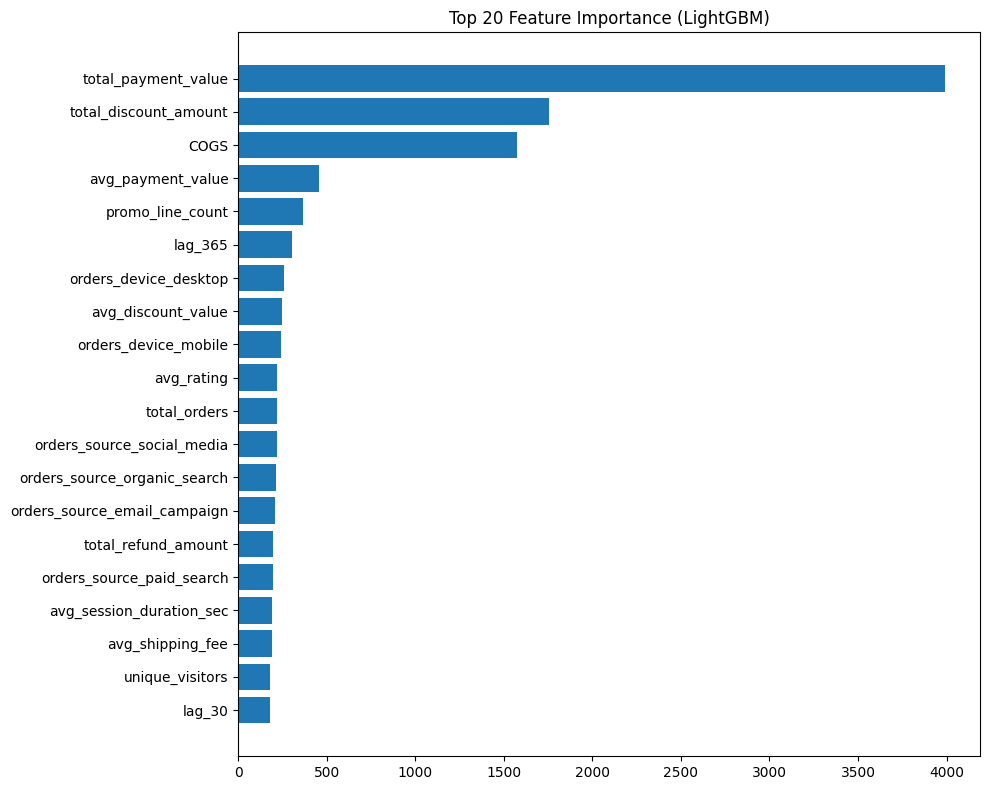

,feature,importance
19,total_payment_value,3989
23,total_discount_amount,1758
0,COGS,1573
20,avg_payment_value,454
24,promo_line_count,366
53,lag_365,307
10,orders_device_desktop,261
27,avg_discount_value,250
11,orders_device_mobile,243
32,avg_rating,218


In [ ]:
# Gain importance
imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
topn = imp.head(20).iloc[::-1]
plt.barh(topn["feature"], topn["importance"])
plt.title("Top 20 Feature Importance (LightGBM)")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_top20.png", dpi=200)
plt.show()

imp.to_csv(PROJECT_ROOT / "report" / "feature_importance.csv", index=False)
imp.head(20)

In [ ]:
# Reproducibility note
print("Khong cai package truc tiep trong notebook de dam bao tinh tai lap.")
print("Neu thieu SHAP, cai ngoai notebook: pip install shap==0.48.0")

Note: you may need to restart the kernel to use updated packages.


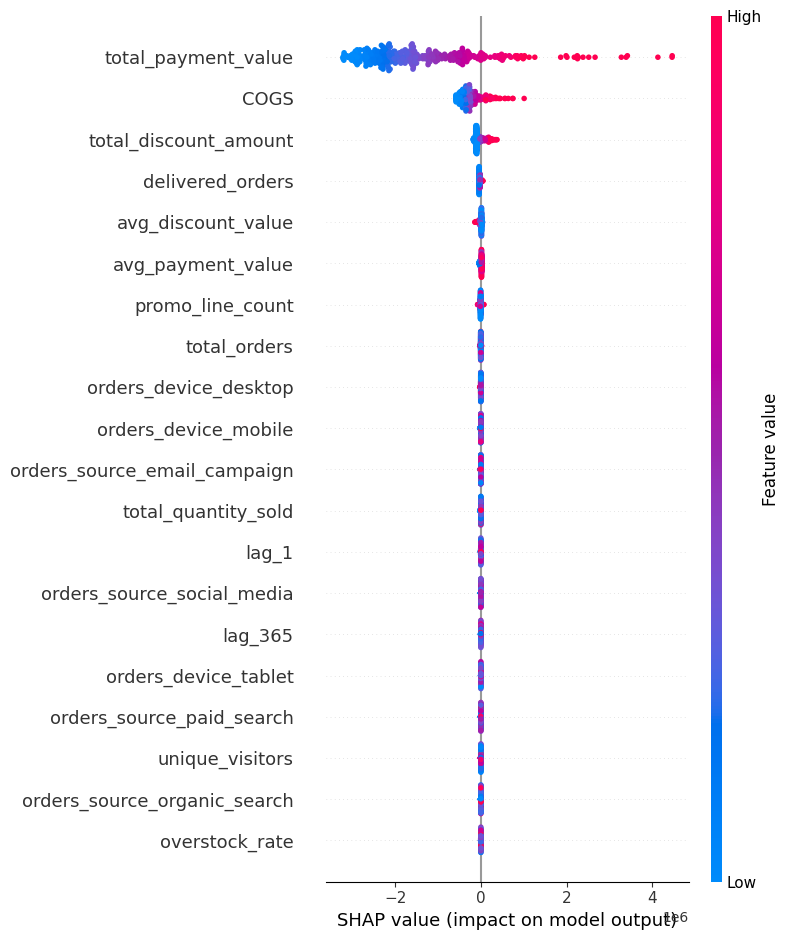

In [ ]:
# SHAP
if HAS_SHAP:
    sample_n = min(2000, len(X_valid))
    X_sample = X_valid.sample(sample_n, random_state=42)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    plt.figure()
    shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "shap_summary.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("SHAP not installed. Run: pip install shap")

In [ ]:
# Leakage checklist for technical report
leakage_checklist = [
    "# Leakage Checklist - Revenue Forecasting",
    "",
    "## 1) Time split",
    "- [x] Khong random split.",
    "- [x] Chia train/valid theo thu tu thoi gian.",
    "",
    "## 2) Lag/Rolling features",
    "- [x] Rolling Revenue dung shift(1) truoc rolling de tranh nhin ngay hien tai.",
    "- [x] Lag chi su dung du lieu qua khu (lag_1, lag_7, lag_14, lag_30, lag_365).",
    "",
    "## 3) Exogenous features governance",
    "- [ ] Da xac nhan cut-off thoi diem du bao cho tung bien cung ngay (orders/payments/returns/shipments).",
    "- [ ] Neu du bao dau ngay, cac bien cung ngay phai duoc lag it nhat 1 ngay.",
    "",
    "## 4) Validation protocol",
    "- [x] Co baseline bat buoc (lag_1, lag_365).",
    "- [x] Co walk-forward evaluation de kiem tra do on dinh theo thoi gian.",
    "",
    "## 5) Reproducibility",
    "- [x] Co random seed cho model va sampling.",
    "- [x] Khong cai package truc tiep trong notebook.",
    "",
    "## 6) Explainability",
    "- [x] Co feature importance.",
    "- [x] Co SHAP summary plot.",
    "- [ ] Da dien giai bang ngon ngu kinh doanh trong report (marketing, inventory, fulfillment)."
]

checklist_path = PROJECT_ROOT / "report" / "leakage_checklist.md"
with open(checklist_path, "w", encoding="utf-8") as f:
    f.write("\n".join(leakage_checklist))

print("Saved leakage checklist:", checklist_path)

Saved leakage checklist: D:\UNIVERSITY\PERSONAL_PROJECT\datathon\report\leakage_checklist.md
